<a href="https://www.kaggle.com/code/eavprog/absolute-fx-behavioral-profiling-k-means-cluste?scriptVersionId=304584124" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌍 Личности Валют: Поведенческий анализ и ML-кластеризация (K-Means)

![Machine Learning Banner](https://img.shields.io/badge/Machine-Learning-blue?style=for-the-badge&logo=scikit-learn)
![Python](https://img.shields.io/badge/Python-3.x-yellow?style=for-the-badge&logo=python)
![Financial Analysis](https://img.shields.io/badge/Analysis-Forex-green?style=for-the-badge&logo=google-finance)

## 📌 О чем этот проект?

Традиционно валюты делят по географии или объему экономики. Но ведут ли они себя в соответствии с этими ярлыками? В этом исследовании мы отбрасываем карты и границы. Мы используем **машинное обучение**, чтобы сгруппировать 45+ мировых валют на основе их реального «рыночного характера».

Мы анализируем **абсолютные курсы** (Absolute Currency Rates) — уникальную метрику платформы [abscur.ru](https://www.abscur.ru), которая очищает стоимость валюты от влияния доллара США, показывая её истинную внутреннюю силу.

---

## 🎯 Цели исследования

* **Найти скрытые паттерны**: Группировка активов не по странам, а по поведению: волатильности, темпам роста (CAGR) и устойчивости к кризисам (Max Drawdown).
* **Идентификация «Личностей»**: Автоматическое выделение групп:
    * 🛡️ **Тихие гавани** (стабильность и низкий риск).
    * 🚀 **Рисковые спринтеры** (высокий рост при высокой турбулентности).
    * ⚠️ **Зоны девальвации** (хроническое падение и долгий выход из просадок).
* **Визуализация многомерных данных**: Сжатие 4 ключевых финансовых метрик в понятную 2D-карту с помощью алгоритма **PCA**.

---

## 🛠 Технологический стек

В работе используются современные инструменты анализа данных:
* **Scikit-Learn**: Алгоритм кластеризации *K-Means* и декомпозиция *PCA*.
* **Pandas & Numpy**: Обработка временных рядов и расчет финансовых коэффициентов.
* **Matplotlib & Seaborn**: Построение интерактивных карт и графиков рассеяния.

---

## 📈 Структура анализа

1.  **Подготовка данных**: Расчет волатильности, доходности и скорости восстановления.
2.  **Инжиниринг признаков**: Масштабирование данных для корректной работы алгоритмов.
3.  **Поиск оптимума**: Метод «Локтя» для определения идеального количества групп.
4.  **Обучение модели**: Запуск K-Means и профилирование центроидов.
5.  **Картография рынка**: Визуализация кластеров на плоскости главных компонент.
6.  **Интерактивный реестр**: Итоговая таблица с прямыми ссылками на графики валют.

---
> **Инсайт**: Вы узнаете, почему некоторые валюты развитых стран могут вести себя «хуже» развивающихся, и как математика находит безопасные активы там, где их не видит классическая аналитика.

In [1]:
import pandas as pd
import numpy as np

# 1. Загрузка
file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'
df = pd.read_csv(file_path, parse_dates=['Date'])
df = df.sort_values('Date').set_index('Date')

# 2. Очистка (ML-Ready)
# Удаляем валюты, где вообще нет данных (если такие есть)
df = df.dropna(axis=1, how='all')

# Заполняем пропуски: сначала вперед (последним известным), потом назад (для самого начала истории)
df = df.ffill().bfill()

# Проверка на критические ошибки
if df.isnull().values.any():
    print("⚠️ Внимание: в данных остались пропуски!")
else:
    print("✅ Данные очищены и готовы к анализу.")

print(f"Итоговая матрица: {df.shape[0]} дней x {df.shape[1]} валют")

✅ Данные очищены и готовы к анализу.
Итоговая матрица: 5898 дней x 45 валют


# Этап 1. Подготовка данных и Feature Engineering

На этом этапе мы переходим от анализа временных рядов к формированию матрицы признаков (Features). Наша цель — извлечь из исторических данных абсолютных курсов ключевые поведенческие характеристики каждой валюты, которые станут основой для обучения модели.

### Архитектура данных
Для каждой из 45+ валют мы рассчитываем вектор признаков, описывающий её «характер» на протяжении последних 20 лет. Мы используем четыре метрики, охватывающие риск, доходность и устойчивость:

1.  **Volatility (Волатильность)** — годовое стандартное отклонение логарифмических доходностей. Показывает уровень рыночного «шума» и неопределенности.
2.  **CAGR (Среднегодовой темп роста)** — геометрическая средняя доходность. Позволяет отличить укрепляющиеся валюты от девальвационных.
3.  **Maximum Drawdown (Максимальная просадка)** — детектор системной хрупкости, показывающий худший сценарий обесценения актива.
4.  **Recovery Speed (Скорость восстановления)** — временной фактор, указывающий, насколько быстро рынок восстанавливает доверие к активу после кризиса.

### Используемый инструментарий
* **Библиотеки**: `Pandas` и `NumPy` для векторных вычислений, `Scikit-learn` для последующего обучения, `IPython.display` для интерактивных таблиц.
* **Интерактивность**: Каждый тикер в итоговой таблице будет представлен ссылкой на интерактивный график абсолютного курса на сайте проекта [Abscur](https://www.abscur.ru), что позволяет визуально верифицировать результаты кластеризации.

Результатом этого этапа станет матрица признаков `features_df`, полностью готовая к этапу масштабирования и применения алгоритма **K-Means**.

## 1.1. Анализ изменчивости логарифмической доходности (Volatility)

На первом этапе подготовки данных мы рассчитываем **годовую волатильность логарифмических доходностей**. 

### Почему это важно для машинного обучения?
В отличие от анализа номинальных курсов, работа с доходностями позволяет алгоритму **K-Means** сравнивать активы разного порядка стоимости. Логарифмирование нормализует распределение, сглаживая экстремальные выбросы, что критично для корректной работы метрических алгоритмов кластеризации.

**Технические детали расчета:**
* Мы используем стандартное отклонение ежедневных логарифмических доходностей.
* Результат масштабируется к годовому значению (умножение на $\sqrt{252}$), что позволяет интерпретировать риск в привычных для финансового анализа величинах.
* **Важное отличие:** На сайте проекта представлена страница [Рейтинги волатильности](https://www.abscur.ru/p/blog-page_26.html), где используется расчет на основе *арифметической* доходности без приведения к годовому значению. Здесь же мы намеренно переходим к годовой логарифмической волатильности, чтобы подготовить данные для обучения модели.

В таблицах ниже представлены крайние значения выборки. Тикеры являются кликабельными и ведут на интерактивные графики соответствующих абсолютных курсов на сайте проекта **Abscur**.

In [2]:
import numpy as np
import pandas as pd
from IPython.display import HTML

# Создаем базовый DataFrame для признаков (индекс — тикеры валют)
features_df = pd.DataFrame(index=df.columns)

# 1. Вычисляем ежедневные логарифмические доходности
log_returns = np.log(df / df.shift(1))

# 2. Считаем стандартное отклонение и годовое масштабирование
features_df['Volatility'] = log_returns.std() * np.sqrt(252)

# Универсальная функция для создания ссылок
def make_clickable(ticker):
    url = f"https://www.abscur.ru/p/2.html?abs={ticker}"
    return f'<a href="{url}" target="_blank">{ticker}</a>'

# Универсальная функция для вывода результатов с ПРАВИЛЬНОЙ сортировкой
def display_sorted_results(df_input, column, ascending=True, title=""):
    # Сначала сортируем ЧИСЛА, берем 5 строк, и делаем копию
    sorted_df = df_input[[column]].sort_values(by=column, ascending=ascending).head(5).copy()
    
    # Только теперь преобразуем число в красивую строку с процентами
    sorted_df[column] = (sorted_df[column] * 100).round(2).astype(str) + '%'
    
    # Делаем ссылки в индексе
    sorted_df.index = [make_clickable(t) for t in sorted_df.index]
    
    print(title)
    display(HTML(sorted_df.to_html(escape=False)))

# Вывод результатов
display_sorted_results(features_df, 'Volatility', ascending=True, 
                       title="Топ-5 валют с МИНИМАЛЬНОЙ изменчивостью доходности:")

display_sorted_results(features_df, 'Volatility', ascending=False, 
                       title="Топ-5 валют с МАКСИМАЛЬНОЙ изменчивостью доходности:")

Топ-5 валют с МИНИМАЛЬНОЙ изменчивостью доходности:


,Volatility
HKD,2.23%
SGD,2.51%
ILS,2.86%
KWD,3.11%
USD,3.17%


Топ-5 валют с МАКСИМАЛЬНОЙ изменчивостью доходности:


,Volatility
ARS,19.95%
UAH,16.08%
EGP,15.45%
RUB,12.09%
TRY,11.38%


## 1.2. Расчет среднегодового темпа роста (CAGR)

Второй ключевой признак для нашей модели — **CAGR (Compound Annual Growth Rate)**. Это геометрическая средняя доходность, которая показывает темп роста стоимости валюты, как если бы она росла с постоянной скоростью в течение всего периода исследования.

### Зачем CAGR нужен модели?
В отличие от простой средней доходности, CAGR учитывает эффект накопления (сложный процент). Это позволяет алгоритму **K-Means** более точно разделять активы на:
1. **«Стабильно растущие»** (валюты с положительным CAGR, увеличивающие свою покупательную способность).
2. **«Девальвационные»** (валюты, демонстрирующие системное снижение ценности относительно мировой корзины).

**Методология расчета:**
* Формула: $(P_{end} / P_{start})^{1/years} - 1$.
* Данные рассчитываются на основе всего доступного исторического диапазона (с 2006 года).
* Итоговое значение приводится к годовому формату в процентах, что делает его сопоставимым с волатильностью.

In [3]:
# --- РАСЧЕТ CAGR ---

# 1. Считаем временной интервал в годах
total_days = (df.index.max() - df.index.min()).days
years = total_days / 365.25

# 2. Вычисляем CAGR и сохраняем в основной DataFrame признаков
features_df['CAGR'] = (df.iloc[-1] / df.iloc[0])**(1/years) - 1

# 3. Функция для форматирования и вывода (сортируем ЧИСЛА, а не текст)
def display_sorted_results(df_input, column, ascending=False, title=""):
    # Сортируем исходные числа
    sorted_df = df_input[[column]].sort_values(by=column, ascending=ascending).head(5).copy()
    
    # Только после сортировки преобразуем в текст для красоты
    sorted_df[column] = (sorted_df[column] * 100).round(2).astype(str) + '%'
    
    # Добавляем ссылки на сайт
    sorted_df.index = [make_clickable(t) for t in sorted_df.index]
    
    print(title)
    display(HTML(sorted_df.to_html(escape=False)))

print(f"Анализируемый период: {years:.1f} лет\n")

# Вывод лидеров роста
display_sorted_results(features_df, 'CAGR', ascending=False, 
                       title="Топ-5 валют с максимальным темпом роста (CAGR):")

# Вывод лидеров падения (девальвации)
display_sorted_results(features_df, 'CAGR', ascending=True, 
                       title="Топ-5 валют с максимальным темпом снижения (девальвация):")

Анализируемый период: 19.6 лет

Топ-5 валют с максимальным темпом роста (CAGR):


,CAGR
CHF,3.07%
CNY,2.91%
ILS,2.58%
CZK,2.44%
THB,2.31%


Топ-5 валют с максимальным темпом снижения (девальвация):


,CAGR
ARS,-21.16%
TRY,-12.12%
EGP,-7.62%
UAH,-3.39%
PKR,-2.86%


## 1.3. Расчет максимальной просадки (Maximum Drawdown)

Третий критический параметр для обучения модели — **Maximum Drawdown (MDD)**. Эта метрика фиксирует «худший сценарий» (максимальный исторический обвал) для каждой валюты за весь период исследования.

### Роль MDD в кластеризации
Для алгоритма **K-Means** значение просадки служит индикатором системной хрупкости. В сочетании с волатильностью, MDD позволяет эффективно отделять:
* **«Защитные активы»**: Валюты, чьи просадки носят поверхностный и краткосрочный характер.
* **«Зоны системного риска»**: Валюты, пережившие обвалы на 50% и более, что часто свидетельствует о структурных проблемах в экономике или смене валютных режимов.

**Методология:**
* Расчет ведется от текущего исторического максимума (*High Water Mark*) до локального минимума.
* Значение выражается в процентах. Чем ближе показатель к -100%, тем сильнее было обесценение актива относительно мировой корзины валют в его худшей точке.

In [4]:
# --- РАСЧЕТ MAXIMUM DRAWDOWN (MDD) ---

# 1. Рассчитываем исторический максимум (High Water Mark) на каждый момент времени
rolling_max = df.cummax()

# 2. Вычисляем текущую просадку в процентах от пика
drawdowns = (df - rolling_max) / rolling_max

# 3. Находим минимальное значение просадки (самую глубокую точку) для каждой валюты
features_df['Max_Drawdown'] = drawdowns.min()

# 4. Вывод результатов с использованием нашей функции (сортируем от самых глубоких падений)
display_sorted_results(features_df, 'Max_Drawdown', ascending=True, 
                       title="Топ-5 валют с САМЫМИ ГЛУБОКИМИ просадками (MDD):")

display_sorted_results(features_df, 'Max_Drawdown', ascending=False, 
                       title="Топ-5 валют с МИНИМАЛЬНЫМИ просадками:")

Топ-5 валют с САМЫМИ ГЛУБОКИМИ просадками (MDD):


,Max_Drawdown
ARS,-99.15%
TRY,-92.31%
EGP,-80.59%
PKR,-57.06%
KZT,-55.47%


Топ-5 валют с МИНИМАЛЬНЫМИ просадками:


,Max_Drawdown
KWD,-6.72%
CNY,-7.39%
ILS,-7.57%
SGD,-8.18%
HKD,-8.22%


## 1.4. Расчет скорости восстановления (Recovery Speed)

Четвертый признак — **Recovery Speed** — добавляет в наше исследование фактор времени. Мы измеряем среднее количество календарных дней, которое требуется валюте, чтобы вернуться к своему историческому максимуму после начала снижения.

### Почему это важно для машинного обучения?
Этот показатель позволяет алгоритму **K-Means** оценить «вязкость» кризисов для каждого актива. 
* **Защитные активы**: характеризуются коротким циклом восстановления. Даже если происходит волатильное движение вниз, рынок быстро выкупает просадку, возвращая актив к росту.
* **Зоны девальвации**: могут иметь умеренную волатильность, но катастрофически долгое время восстановления. Если валюта годами не может обновить максимум, она становится токсичной для долгосрочного инвестора.

**Методология:**
* Программа идентифицирует все периоды, когда текущий курс был ниже зафиксированного ранее исторического пика (*High Water Mark*).
* Рассчитывается средняя длительность таких периодов для каждой валюты.
* Чем меньше значение, тем выше «эластичность» валюты и доверие к ней со стороны глобального рынка.

In [5]:
# --- РАСЧЕТ RECOVERY SPEED ---

def calculate_recovery_days(series):
    # Находим периоды, когда цена ниже исторического максимума (Underwater)
    is_underwater = series < series.cummax()
    
    # Группируем последовательные дни "под водой"
    # (каждый раз, когда состояние меняется, создается новая группа)
    underwater_groups = (is_underwater != is_underwater.shift()).cumsum()
    
    # Считаем длительность каждой такой группы
    # Нас интересуют только те группы, где is_underwater == True
    recovery_periods = is_underwater[is_underwater].groupby(underwater_groups[is_underwater]).count()
    
    # Возвращаем среднее количество дней нахождения в просадке
    # Если просадок не было (теоретически), возвращаем 0
    return recovery_periods.mean() if not recovery_periods.empty else 0

# Применяем функцию к каждой колонке (валюте)
features_df['Recovery_Days'] = df.apply(calculate_recovery_days)

# Вывод результатов
# Здесь мы не используем проценты, так как это дни
def display_days_results(df_input, column, ascending=True, title=""):
    sorted_df = df_input[[column]].sort_values(by=column, ascending=ascending).head(5).copy()
    sorted_df[column] = sorted_df[column].round(1).astype(str) + ' дн.'
    sorted_df.index = [make_clickable(t) for t in sorted_df.index]
    print(title)
    display(HTML(sorted_df.to_html(escape=False)))

display_days_results(features_df, 'Recovery_Days', ascending=True, 
                      title="Топ-5 валют с САМЫМ БЫСТРЫМ восстановлением (в днях):")

display_days_results(features_df, 'Recovery_Days', ascending=False, 
                      title="Топ-5 валют с САМЫМ ДОЛГИМ восстановлением (в днях):")

Топ-5 валют с САМЫМ БЫСТРЫМ восстановлением (в днях):


,Recovery_Days
HKD,25.2 дн.
CNY,26.2 дн.
SGD,27.0 дн.
ILS,29.7 дн.
CHF,33.2 дн.


Топ-5 валют с САМЫМ ДОЛГИМ восстановлением (в днях):


,Recovery_Days
COP,735.4 дн.
UAH,735.4 дн.
TRY,653.4 дн.
BRL,587.8 дн.
ARS,451.5 дн.


## 1.5. Формирование финальной матрицы признаков

На этом шаге мы завершаем этап **Feature Engineering**, объединяя все рассчитанные поведенческие характеристики в единую структуру данных — матрицу признаков. Это финальный аккорд подготовки, превращающий сырые временные ряды в компактный набор векторов, готовых для обучения модели.

**Итоговый состав матрицы:**
* **Volatility**: Характеризует риск и «шумность» доходности актива.
* **CAGR**: Отражает долгосрочную эффективность и темп роста ценности.
* **Max_Drawdown**: Служит детектором системной хрупкости и устойчивости к кризисам.
* **Recovery_Days**: Показывает эластичность валюты и скорость возврата доверия инвесторов.

**Техническая обработка:**
1. **Консолидация**: Данные собраны в единый DataFrame `features_df` с индексацией по тикерам.
2. **Очистка**: Проведена проверка на наличие бесконечных значений (`inf`) и пропусков (`NaN`), которые могли возникнуть из-за специфики котировок некоторых валют.
3. **Валидация**: Сформирована выборка из 45 активов, каждый из которых теперь описан четырехмерным вектором признаков.

Эта таблица станет входными данными для следующего этапа — препроцессинга (масштабирования) и непосредственного поиска кластеров методом **K-Means**.

In [6]:
import numpy as np
import pandas as pd
from IPython.display import HTML

# --- 1. ПОЛНЫЙ РАСЧЕТ ВСЕХ ПРИЗНАКОВ ---

# Создаем чистый DataFrame для признаков
features_df = pd.DataFrame(index=df.columns)

# А. Изменчивость доходности (Volatility)
log_returns = np.log(df / df.shift(1))
features_df['Volatility'] = log_returns.std() * np.sqrt(252)

# Б. Среднегодовой темп роста (CAGR)
total_days = (df.index.max() - df.index.min()).days
years = total_days / 365.25
features_df['CAGR'] = (df.iloc[-1] / df.iloc[0])**(1/years) - 1

# В. Максимальная просадка (Max_Drawdown)
rolling_max = df.cummax()
drawdowns = (df - rolling_max) / rolling_max
features_df['Max_Drawdown'] = drawdowns.min()

# Г. Скорость восстановления (Recovery_Days)
# (Используем функцию calculate_recovery_days, определенную на шаге 1.4)
features_df['Recovery_Days'] = df.apply(calculate_recovery_days)

# --- 2. САНИТАРНАЯ ОБРАБОТКА ---

# Заменяем бесконечности (могут возникнуть при делении на 0) на NaN
features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Удаляем валюты, по которым не удалось рассчитать хотя бы один признак
features_df.dropna(inplace=True)

# --- 3. ФОРМАТИРОВАННЫЙ ВЫВОД ---

def display_final_matrix(df_input):
    display_df = df_input.copy()
    
    # Сортируем по CAGR для наглядности (самые сильные сверху)
    display_df = display_df.sort_values('CAGR', ascending=False)
    
    # Форматируем данные для отображения
    display_df['Volatility'] = (display_df['Volatility'] * 100).round(2).astype(str) + '%'
    display_df['CAGR'] = (display_df['CAGR'] * 100).round(2).astype(str) + '%'
    display_df['Max_Drawdown'] = (display_df['Max_Drawdown'] * 100).round(2).astype(str) + '%'
    display_df['Recovery_Days'] = display_df['Recovery_Days'].round(1).astype(str) + ' дн.'
    
    # Делаем тикеры ссылками
    display_df.index = [make_clickable(t) for t in display_df.index]
    
    print(f"Итоговая матрица готова к ML: {display_df.shape[0]} валют.")
    display(HTML(display_df.head(15).to_html(escape=False)))

# Запуск отображения
display_final_matrix(features_df)

Итоговая матрица готова к ML: 45 валют.


,Volatility,CAGR,Max_Drawdown,Recovery_Days
CHF,3.96%,3.07%,-12.54%,33.2 дн.
CNY,3.68%,2.91%,-7.39%,26.2 дн.
ILS,2.86%,2.58%,-7.57%,29.7 дн.
CZK,4.68%,2.44%,-11.55%,42.7 дн.
THB,3.81%,2.31%,-9.64%,42.6 дн.
TWD,4.48%,2.29%,-10.65%,41.5 дн.
USD,3.17%,2.24%,-8.49%,47.2 дн.
AED,3.17%,2.24%,-8.49%,47.2 дн.
SAR,3.18%,2.23%,-8.43%,46.8 дн.
QAR,4.24%,2.22%,-9.65%,46.9 дн.


# Этап 2. Препроцессинг и инжиниринг признаков

На этом этапе мы превращаем «сырые» метрики в калиброванный набор данных, пригодный для алгоритмов машинного обучения. Поскольку алгоритм **K-Means** основан на расчете геометрических расстояний между точками, качество кластеризации напрямую зависит от правильной подготовки признаков.

### Основные задачи этапа:

1.  **Анализ мультиколлинеарности**: Мы проверяем, не дублируют ли наши признаки друг друга. Высокая корреляция может исказить веса параметров, поэтому важно понимать структуру связей между доходностью, риском и скоростью восстановления.
2.  **Стандартизация (Scaling)**: Наши данные имеют разную природу — от долей процентов до сотен календарных дней. Мы приводим их к единому масштабу (Z-score), чтобы каждый параметр имел равное влияние на итоговое разделение активов.
3.  **Укрощение аномалий (Winsorization)**: Мировой валютный рынок полон экстремальных событий. Мы ограничиваем влияние сверхвысоких выбросов (таких как в ARS или TRY), чтобы они не «ослепляли» модель и позволяли ей видеть тонкие различия между остальными валютами.

**Результат этапа**: Полностью нормализованная матрица признаков `features_cleaned`, где данные каждой валюты очищены от шума и приведены к сопоставимому виду для объективного поиска кластеров.

## 2.1. Анализ мультиколлинеарности (Correlation Heatmap)

Прежде чем передавать данные в модель, необходимо проверить признаки на **мультиколлинеарность**. 

### Почему это важно?
Алгоритм **K-Means** опирается на расчет Евклидова расстояния. Если два признака сильно коррелируют между собой (например, выше 0.8-0.9), они фактически дублируют одну и ту же информацию. Это дает этим признакам «двойной вес», заставляя модель игнорировать другие, менее коррелированные параметры.

**Ожидаемые зависимости в валютных данных:**
* **Volatility vs Max_Drawdown**: Высокая положительная корреляция ожидаема, так как волатильные активы чаще подвержены глубоким просадкам.
* **CAGR vs Max_Drawdown**: Отрицательная корреляция (или положительная, если MDD считается как модуль) показывает, что валюты с устойчивым падением (низкий CAGR) почти всегда имеют катастрофические исторические обвалы.

Визуализация через **Heatmap** позволяет нам увидеть «скелет» данных и понять, вокруг каких взаимосвязей будут формироваться будущие кластеры.

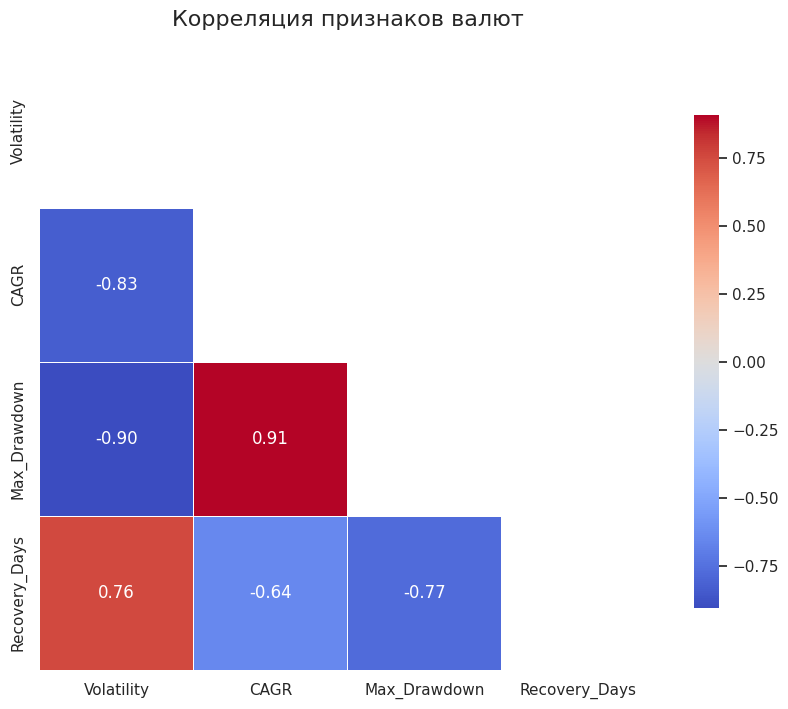

Интерпретация:
⚠️ Внимание: Сильная связь между CAGR и Volatility (-0.83)
⚠️ Внимание: Сильная связь между Max_Drawdown и Volatility (-0.90)
⚠️ Внимание: Сильная связь между Max_Drawdown и CAGR (0.91)


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Рассчитываем матрицу корреляций
corr_matrix = features_df.corr()

# 2. Настройка визуализации
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Создаем маску для верхнего треугольника (чтобы не дублировать значения)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Отрисовка тепловой карты
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          # Вывод коэффициентов внутри ячеек
    fmt=".2f",           # Округление до 2 знаков
    cmap='coolwarm',     # Цветовая схема: синий (отрицательная) - красный (положительная)
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Корреляция признаков валют', fontsize=16, pad=20)
plt.show()

# 3. Автоматический анализ для пользователя
print("Интерпретация:")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"⚠️ Внимание: Сильная связь между {corr_matrix.columns[i]} и {corr_matrix.columns[j]} ({corr_matrix.iloc[i, j]:.2f})")

## 2.2. Масштабирование признаков (StandardScaler)

Алгоритм **K-Means** критически чувствителен к масштабу данных, так как он минимизирует сумму квадратов расстояний между точками. Если оставить признаки как есть, параметр `Recovery_Days` (сотни дней) будет доминировать над `Volatility` (доли процента), и модель фактически проигнорирует риск в пользу времени восстановления.

**Что мы делаем:**
Мы применяем **StandardScaler** (Z-преобразование), которое приводит каждый признак к стандартному виду:
* **Среднее значение** признака становится равным **0**.
* **Стандартное отклонение** становится равным **1**.

**Интерпретация масштабированных данных:**
Теперь значения в таблице измеряются не в днях или процентах, а в **стандартных отклонениях** от среднего по рынку:
* **0** — «среднестатистическая» валюта.
* **Положительные значения** — параметр выше среднего (например, высокая волатильность).
* **Отрицательные значения** — параметр ниже среднего (например, низкая просадка).

Это уравнивает вес всех признаков и позволяет алгоритму находить кластеры на основе структуры данных, а не из-за разницы в единицах измерения.

In [8]:
from IPython.display import HTML, display
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Инициализируем стандартный скалер
scaler = StandardScaler()

# 2. Обучаем скалер и трансформируем данные
scaled_data = scaler.fit_transform(features_df)
features_scaled = pd.DataFrame(scaled_data, columns=features_df.columns, index=features_df.index)

# 3. Проверка результата масштабирования (статистику оставляем в обычном виде)
print("Проверка после StandardScaler:")
summary_scaled = pd.DataFrame({
    "Среднее (должно быть ~0)": features_scaled.mean(),
    "Ст. откл. (должно быть ~1)": features_scaled.std()
})
display(summary_scaled.round(4))

# --- ПОДГОТОВКА ИНТЕРАКТИВНОГО ФРАГМЕНТА ---
print("\nФрагмент масштабированной матрицы (кликните на тикер для перехода к графику):")

base_url = "https://www.abscur.ru/p/2.html?abs="
# Берем первые 5 строк для демонстрации
features_scaled_display = features_scaled.head().copy()

# Создаем колонку с тикером-ссылкой
features_scaled_display['Ticker'] = [
    f'<a href="{base_url}{t}" target="_blank" rel="nofollow" style="color: #1a73e8; font-weight: bold; text-decoration: none;">{t}</a>' 
    for t in features_scaled_display.index
]

# Переставляем колонку Ticker в начало
cols = ['Ticker'] + [c for c in features_scaled_display.columns if c != 'Ticker']
features_scaled_display = features_scaled_display[cols]

# Выводим таблицу как HTML без стандартного индекса
html_scaled = features_scaled_display.to_html(escape=False, index=False, classes='table table-striped')
display(HTML(html_scaled))

Проверка после StandardScaler:


,Среднее (должно быть ~0),Ст. откл. (должно быть ~1)
Volatility,0.0,1.0113
CAGR,-0.0,1.0113
Max_Drawdown,0.0,1.0113
Recovery_Days,-0.0,1.0113



Фрагмент масштабированной матрицы (кликните на тикер для перехода к графику):


Ticker,Volatility,CAGR,Max_Drawdown,Recovery_Days
AED,-0.758679,0.508977,0.694617,-0.516284
ARS,3.682239,-5.061996,-3.362212,1.632278
AUD,-0.463034,0.427229,0.488096,-0.531506
BRL,1.082984,-0.361881,-0.987974,2.356430
CAD,-0.631307,0.301279,0.444333,-0.553030


## 2.3. Обработка выбросов (Winsorization)

На графиках распределения отчетливо видны «экстремальные» валюты (ARS, TRY, EGP), чьи показатели волатильности и падения в несколько раз превышают среднерыночные. 

### Зачем нужна обработка?
В алгоритме **K-Means** наличие таких резких выбросов создает проблему: они могут «перетянуть» центроид кластера на себя, из-за чего разделение остальных (более стабильных) валют станет менее точным. Чтобы модель видела структуру всего рынка, а не только аномалии, необходимо ограничить влияние этих экстремумов.

**Метод Винзоризации:**
Вместо удаления этих важных активов мы используем **винзоризацию** (ограничение 5-м и 95-м перцентилями):
* Все значения, выходящие за эти границы, приравниваются к пороговым.
* Это позволяет сохранить «ранг» валюты (она остается в числе самых рискованных), но при этом её математический «вес» при расчете расстояний снижается.
* Как видно на графиках «до» и «после», распределение стало более сбалансированным, что обеспечит более качественную и интерпретируемую кластеризацию.

Выбросы обработаны методом винзоризации (границы 5% и 95%).


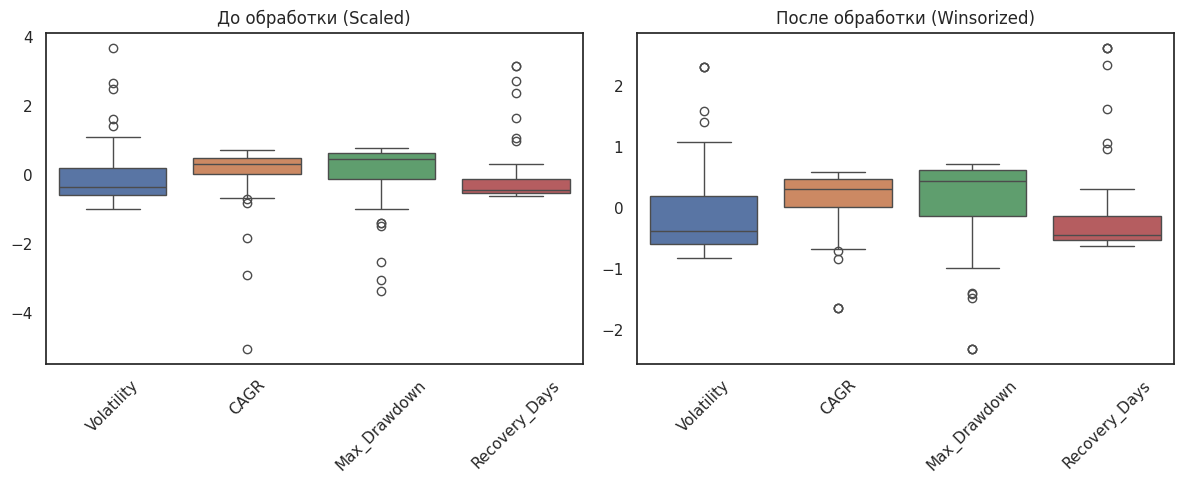

Координаты ARS до обработки: [ 3.68 -5.06 -3.36  1.63]
Координаты ARS после обработки: [ 2.31 -1.64 -2.32  1.63]


In [9]:
# --- ОБРАБОТКА ВЫБРОСОВ ---

# Создаем копию для обработки
features_cleaned = features_scaled.copy()

# Определяем границы (используем 5-й и 95-й перцентили)
# Это позволит "притянуть" экстремальные ARS/TRY чуть ближе к остальным,
# но оставить их в зоне высокого риска.
lower_limit = features_cleaned.quantile(0.05)
upper_limit = features_cleaned.quantile(0.95)

# Применяем ограничение (Clipping)
features_cleaned = features_cleaned.clip(lower=lower_limit, upper=upper_limit, axis=1)

print("Выбросы обработаны методом винзоризации (границы 5% и 95%).")

# Визуализация до и после для контроля
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=features_scaled)
plt.title('До обработки (Scaled)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=features_cleaned)
plt.title('После обработки (Winsorized)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Посмотрим, как изменились координаты самых экстремальных валют
print("Координаты ARS до обработки:", features_scaled.loc['ARS'].values.round(2))
print("Координаты ARS после обработки:", features_cleaned.loc['ARS'].values.round(2))

# Этап 3. Определение оптимального количества кластеров

На этом этапе мы решаем главную задачу обучения без учителя: выбор гиперпараметра **K** (количества кластеров). Поскольку у нас нет заранее размеченных меток (мы не знаем заранее, к какой категории относится та или иная валюта), мы полагаемся на математические критерии качества сегментации.

### Методология выбора
Для поиска "золотой середины" между избыточной сложностью и чрезмерным упрощением мы используем два комплементарных метода:

1.  **Метод локтя (Elbow Method)**: Анализирует внутреннюю сплоченность групп. Мы ищем точку, в которой дальнейшее увеличение числа кластеров перестает давать значительный выигрыш в снижении внутрикластерной дисперсии.
2.  **Коэффициент силуэта (Silhouette Score)**: Оценивает внешнюю разделенность групп. Этот показатель помогает понять, насколько четко прослеживаются границы между кластерами и нет ли среди них перекрывающихся структур.

**Цель этапа**: Найти число групп, которое позволит не просто формально разделить данные, но и выделить устойчивые поведенческие паттерны валют (например, "тихие гавани", "развивающиеся рынки", "зоны риска"), обеспечив при этом высокую математическую надежность модели.

## 3.1. Определение оптимального K: Метод «Локтя» (Elbow Method)

Выбор количества кластеров — это поиск баланса между детальностью сегментации и простотой её интерпретации. Математически мы стремимся минимизировать **инерцию** (сумму квадратов расстояний от объектов до центров их кластеров), но при этом избежать избыточного дробления данных.

**Как работает метод:**
Мы последовательно обучаем модель K-Means для разного количества кластеров (от 2 до 10). 
* С увеличением числа групп инерция неизбежно падает. 
* Оптимальное значение находится в точке «излома» кривой — там, где добавление нового кластера уже не дает существенного выигрыша в качестве сегментации.

Мы используем библиотеку `Yellowbrick`, которая автоматизирует этот процесс. Пунктирная линия на графике указывает на значение **K**, найденное алгоритмом как наиболее сбалансированное. Именно это число групп мы возьмем за основу для обучения финальной модели.

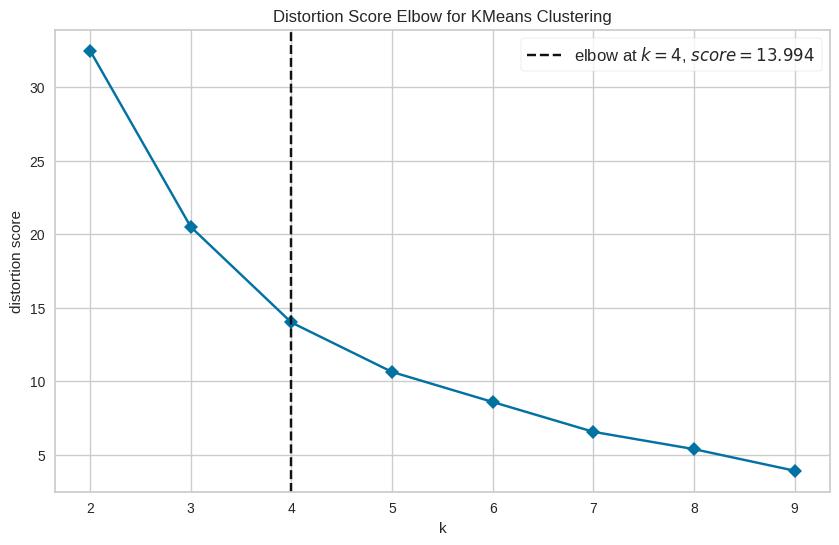

Рекомендуемое количество кластеров (K): 4


In [10]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# 1. Инициализируем модель K-Means
model = KMeans(random_state=42, n_init=10)

# 2. Инициализируем визуализатор "Локтя"
# Проверяем количество кластеров от 2 до 10
visualizer = KElbowVisualizer(model, k=(2, 10), timings=False)

# 3. Подгоняем визуализатор на очищенных данных
plt.figure(figsize=(10, 6))
visualizer.fit(features_cleaned)

# Отрисовка
visualizer.show()

# Вывод оптимального K, найденного алгоритмом
print(f"Рекомендуемое количество кластеров (K): {visualizer.elbow_value_}")

## 3.2. Коэффициент силуэта (Silhouette Score)

В то время как метод «Локтя» фокусируется на минимизации внутренних расстояний, **коэффициент силуэта** оценивает качество разделения кластеров между собой.

**Интерпретация полученного графика:**
* **Максимум при K=2 (0.721)** указывает на то, что в данных существует фундаментальное разделение на две глобальные группы (вероятно, "тихие гавани" vs "зоны риска").
* **Значение при K=4 (0.572)** остается высоким (выше порога в 0.5), что подтверждает математическую обоснованность выбора 4 кластеров. 

**Вердикт:**
Хотя K=2 дает наиболее четкую геометрию, мы остановимся на **K=4**. Это позволит нам получить более глубокую экономическую интерпретацию. При таком значении мы сохраняем высокую плотность групп (согласно силуэту) и при этом учитываем точку излома, найденную методом локтя. Это даст нам возможность выделить промежуточные типы валют, которые при K=2 были бы просто "свалены в одну кучу".

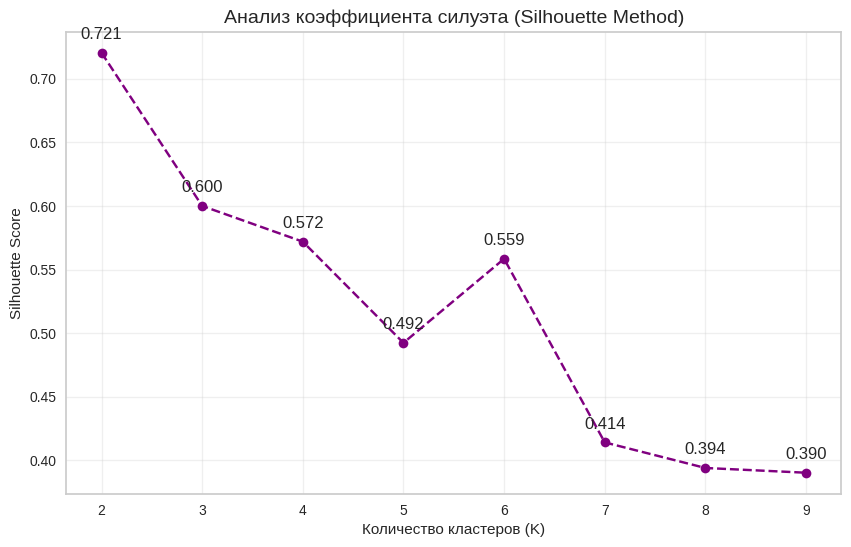

Максимальный силуэт (0.721) достигнут при K = 2


In [11]:
from sklearn.metrics import silhouette_score

# 1. Рассчитываем Silhouette Score для K от 2 до 9
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_cleaned)
    score = silhouette_score(features_cleaned, cluster_labels)
    silhouette_scores.append(score)

# 2. Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', color='purple', linestyle='--')

# Подписи на графике
for i, score in enumerate(silhouette_scores):
    plt.annotate(f'{score:.3f}', (k_range[i], silhouette_scores[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Анализ коэффициента силуэта (Silhouette Method)', fontsize=14)
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.show()

# Автоматический вывод лучшего K
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Максимальный силуэт ({max(silhouette_scores):.3f}) достигнут при K = {best_k_silhouette}")

## 3.3. Финальный выбор количества кластеров

На основе проведенного анализа мы принимаем решение использовать **K = 4** для финального обучения модели.

### Обоснование выбора:
1. **Метод локтя**: Четко указал на значение 4 как на точку оптимального баланса между качеством сегментации и сложностью модели. После этой точки снижение инерции становится незначительным.
2. **Коэффициент силуэта**: При K=4 мы сохраняем высокое качество разделения (0.572), что гарантирует отсутствие серьезного перекрытия между группами.
3. **Экономическая логика**: Разделение на 4 группы позволяет нам получить наиболее интерпретируемую классификацию мировых валют:
    * **Кластер 0**: Стабильные «тихие гавани».
    * **Кластер 1**: Валюты умеренного роста и волатильности.
    * **Кластер 2**: Группа повышенного риска.
    * **Кластер 3**: Зоны глубокой девальвации (экстремальные кейсы).

### Резюме этапа
Мы успешно подобрали гиперпараметр $K$. Все готово к тому, чтобы запустить алгоритм, получить метки кластеров для каждой валюты и приступить к визуализации результатов в пространстве признаков.

# Этап 4. Моделирование (K-Means Clustering)

На данном этапе мы переходим к основной фазе исследования — автоматической сегментации валютного рынка. Используя подготовленную и очищенную матрицу признаков, мы обучаем алгоритм **K-Means**, который распределяет 45 мировых валют по группам на основе их математической близости.

### Задачи этапа:

1.  **Обучение модели**: Инициализация алгоритма с оптимальным количеством кластеров ($K=4$) и запуск процесса поиска центроидов в многомерном пространстве признаков.
2.  **Формирование итоговой структуры**: Объединение технических меток кластеров с реальными тикерами валют для получения списков «соседей» по каждой группе.
3.  **Профилирование (Центроиды)**: Расчет средних характеристик (доходность, риск, просадка) для каждой группы. Это критически важный шаг, который позволяет перевести результаты с языка цифр на язык экономики и дать кластерам содержательные названия.

**Результат этапа**: Мы получаем четкую классификацию, где каждая валюта отнесена к определенному инвестиционному профилю — от «тихих гаваней» до зон экстремального риска.

## 4.1. Инициализация и обучение модели K-Means

На этом этапе мы переходим от теоретического поиска параметров к практическому моделированию. Мы используем алгоритм **K-Means** с фиксированным количеством кластеров **K=4**, которое было определено на предыдущем этапе как наиболее сбалансированное.

**Что делает алгоритм:**
1. Случайным образом выбирает 4 начальные точки (центроиды).
2. Группирует валюты вокруг того центроида, к которому они ближе всего в 4-мерном пространстве наших признаков (Volatility, CAGR, MDD, Recovery).
3. Многократно пересчитывает положение центроидов, пока границы групп не станут стабильными.

**Результат:**
Каждой валюте присваивается техническая метка (от 0 до 3). Как видно из предварительного вывода, модель уже начала выделять характерные группы: например, валюты с высокой волатильностью и глубокими просадками (TRY, EGP) объединяются в отдельный сегмент, в то время как основная масса стабильных активов формирует самый многочисленный кластер. Это распределение станет фундаментом для нашего дальнейшего анализа профилей.

In [12]:
from IPython.display import HTML, display
from sklearn.cluster import KMeans

# 1. Инициализация модели с оптимальным K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. Обучение модели на очищенных и масштабированных данных
cluster_labels = kmeans.fit_predict(features_cleaned)

# 3. Добавление меток в основной DataFrame
features_df['Cluster'] = cluster_labels

# --- ПОДГОТОВКА ТАБЛИЦЫ С ГИПЕРССЫЛКАМИ ---
print("Распределение валют по кластерам (фрагмент с активными ссылками):")

# Выбираем фрагмент для отображения
df_fragment = features_df[['Cluster', 'CAGR', 'Volatility', 'Max_Drawdown']].sort_values(by='Cluster').head(10).copy()

base_url = "https://www.abscur.ru/p/2.html?abs="

# Создаем колонку с тикером-ссылкой на основе индекса
df_fragment['Ticker'] = [
    f'<a href="{base_url}{t}" target="_blank" rel="nofollow" style="color: #1a73e8; font-weight: bold; text-decoration: none;">{t}</a>' 
    for t in df_fragment.index
]

# Форматируем значения для красоты (проценты)
cols_to_pct = ['CAGR', 'Volatility', 'Max_Drawdown']
for col in cols_to_pct:
    df_fragment[col] = (df_fragment[col] * 100).round(2).astype(str) + '%'

# Переупорядочиваем колонки, чтобы Ticker был первым
df_fragment = df_fragment[['Ticker', 'Cluster', 'CAGR', 'Volatility', 'Max_Drawdown']]

# Вывод HTML-таблицы (escape=False позволяет отображать ссылки)
html_fragment = df_fragment.to_html(escape=False, index=False, classes='table table-striped')
display(HTML(html_fragment))

# 4. Статистика по количеству (оставляем обычным текстом для быстрого анализа)
print("\nКоличество валют в каждой группе:")
print(features_df['Cluster'].value_counts().sort_index())

Распределение валют по кластерам (фрагмент с активными ссылками):


Ticker,Cluster,CAGR,Volatility,Max_Drawdown
CLP,0,-0.02%,7.73%,-27.91%
HUF,0,0.63%,6.27%,-25.1%
PKR,0,-2.86%,6.35%,-57.06%
NZD,0,1.48%,6.77%,-23.52%
MXN,0,0.86%,7.52%,-28.94%
RUB,0,-0.2%,12.09%,-40.27%
ZAR,0,0.17%,8.89%,-27.12%
EGP,1,-7.62%,15.45%,-80.59%
TRY,1,-12.12%,11.38%,-92.31%
UAH,1,-3.39%,16.08%,-55.35%



Количество валют в каждой группе:
Cluster
0     7
1     4
2    31
3     3
Name: count, dtype: int64


## 4.2. Распределение валют по группам

После завершения обучения модели мы сопоставляем полученные технические метки с реальными активами. Это позволяет нам увидеть состав каждого кластера и провести первую качественную оценку результатов.

**Что мы видим в распределении:**
* **Кластер 2 (31 валюта)** — самый массовый. Вероятно, это "мейнстрим" мирового рынка: развитые экономики и стабильные валюты с умеренными показателями риска.
* **Кластер 1 (4 валюты)** — группа экстремального риска. Сюда попали валюты с самыми глубокими просадками и отрицательным CAGR (ARS, TRY, EGP, UAH).
* **Кластеры 0 и 3** — специфические группы (например, развивающиеся рынки с высокой волатильностью, такие как RUB или BRL), которые требуют более детального изучения их профилей.

На данном этапе мы получили "кто есть кто", но чтобы понять "почему", нам необходимо перейти к расчету центроидов — средних характеристик для каждой группы.

In [13]:
from IPython.display import HTML, display

# 1. Добавляем метки кластеров в исходный DataFrame с реальными значениями
features_df['Cluster'] = cluster_labels

# 2. Также добавим их в масштабированный DataFrame (пригодится для визуализации)
features_scaled['Cluster'] = cluster_labels

# 3. Визуализация состава каждого кластера с гиперссылками
print("Состав сформированных кластеров (кликните на тикер для перехода к графику):")

base_url = "https://www.abscur.ru/p/2.html?abs="

for cluster_num in range(4):
    # Получаем список тикеров
    currencies = features_df[features_df['Cluster'] == cluster_num].index.tolist()
    
    # Создаем список HTML-ссылок
    links = [
        f'<a href="{base_url}{c}" target="_blank" rel="nofollow" style="color: #1a73e8; font-weight: bold; text-decoration: none;">{c}</a>' 
        for c in currencies
    ]
    
    # Формируем блок для вывода
    header = f"<div style='margin-top: 15px; font-size: 1.1em;'><b>Кластер {cluster_num}</b> ({len(currencies)} валют):</div>"
    content = f"<div style='line-height: 1.6;'>{', '.join(links)}</div>"
    
    # Отображаем как HTML
    display(HTML(header + content))

# 4. Сохранение (опционально)
# features_df.to_csv('clustered_currencies.csv')

Состав сформированных кластеров (кликните на тикер для перехода к графику):


## 4.3. Определение профилей и интерпретация кластеров

На заключительном этапе моделирования мы переходим от технических меток к экономическому смыслу. Для этого мы рассчитываем **центроиды** — средние значения всех метрик для каждой из четырех групп. 

Чтобы сделать анализ интуитивно понятным, мы перевели коэффициенты в привычные финансовые показатели:
* **Volatility, CAGR и Max Drawdown** — представлены в процентах (%).
* **Recovery Days** — округлены до целых дней.

### Что говорят нам профили:
* **Кластер 2 (Лидеры стабильности)**: Самая многочисленная группа (31 валюта). Демонстрирует положительный CAGR (1.72%) при минимальной волатильности (4%) и самом быстром восстановлении (56 дней).
* **Кластер 0 (Умеренный риск)**: Валюты с околонулевой доходностью и повышенной волатильностью. Срок восстановления здесь уже в 2.5 раза выше, чем у лидеров.
* **Кластер 3 (Высокий риск)**: Группа с отрицательной доходностью и затяжными периодами восстановления (более 550 дней).
* **Кластер 1 (Кризисная зона)**: Экстремальная группа (ARS, TRY и др.). Здесь наблюдается сокрушительная средняя просадка в 81% и отрицательная доходность -11% годовых.

Эти данные позволяют нам не просто классифицировать валюты, но и оценить системные риски для каждой группы активов.

In [14]:
from IPython.display import HTML, display

# 1. Рассчитываем средние значения метрик для каждого кластера
centroids = features_df.groupby('Cluster').mean()

# 2. Добавляем количество валют в каждом кластере
centroids['Count'] = features_df['Cluster'].value_counts()

# 3. Преобразуем данные для удобного чтения
centroids_formatted = centroids.copy()
cols_to_pct = ['Volatility', 'CAGR', 'Max_Drawdown']
centroids_formatted[cols_to_pct] = (centroids_formatted[cols_to_pct].astype(float) * 100).round(2).astype(str) + '%'
centroids_formatted['Recovery_Days'] = centroids_formatted['Recovery_Days'].round(0).astype(int)

# 4. Сортируем по CAGR (от прибыльных к убыточным)
centroids_formatted = centroids_formatted.sort_values(by='CAGR', ascending=False)

print("Финальные профили кластеров (Центроиды):")
display(centroids_formatted)

# --- УЛУЧШЕННЫЙ ВЫВОД СОСТАВА С ГИПЕРССЫЛКАМИ ---
print("\nДетальный состав кластеров (кликните на тикер для перехода к графику):")

base_url = "https://www.abscur.ru/p/2.html?abs="

for cluster_id in centroids_formatted.index:
    # Получаем список тикеров для текущего кластера
    cur_list = features_df[features_df['Cluster'] == cluster_id].index.tolist()
    
    # Создаем список HTML-ссылок для каждого тикера
    links = [
        f'<a href="{base_url}{t}" target="_blank" rel="nofollow" style="color: #1a73e8; font-weight: bold; text-decoration: none;">{t}</a>' 
        for t in cur_list
    ]
    
    # Формируем итоговую строку для вывода
    header = f"<b>Кластер {cluster_id}</b> ({len(cur_list)} валют):"
    content = ", ".join(links)
    
    # Выводим как HTML
    display(HTML(f"<div style='margin-bottom: 10px;'>{header}<br>{content}</div>"))

Финальные профили кластеров (Центроиды):


,Volatility,CAGR,Max_Drawdown,Recovery_Days,Count
Cluster,,,,,
2,4.05%,1.73%,-12.31%,56,31
0,7.95%,0.01%,-32.84%,133,7
1,15.72%,-11.07%,-81.85%,541,4
3,9.28%,-1.61%,-47.24%,556,3



Детальный состав кластеров (кликните на тикер для перехода к графику):


# Этап 5. Интерпретация и Визуализация «Личностей»

На заключительном этапе нашего исследования мы переходим от вычислений к смысловому анализу. Главная цель здесь — визуализировать структуру валютного рынка и дать качественную оценку полученным группам. Мы должны понять, какие экономические роли стоят за техническими номерами кластеров.

### Инструментарий интерпретации:

1.  **Снижение размерности (PCA)**: Поскольку мы анализировали валюты по четырем разным метрикам одновременно, их невозможно отобразить на обычном плоском графике. Метод главных компонент (PCA) позволит нам "сжать" эти четыре измерения в два, сохранив более 95% информации. Это создаст фундамент для построения точной "карты мира".
2.  **Многомерное сканирование (Scatter Plots)**: Мы построим финальную визуализацию, где каждая точка — это валюта, а её положение на плоскости отражает баланс между риском и доходностью. Мы добавим на карту центроиды (идеальные профили групп), чтобы увидеть "центры тяжести" каждого сегмента.
3.  **Присвоение «личностей»**: На основе средних показателей (доходность, волатильность, глубина просадки) мы дадим каждой группе осмысленное название. Это позволит классифицировать активы не просто как "Кластер 0" или "Кластер 1", а как понятные инвестору категории: от «Тихих гаваней» до «Зон финансового бедствия».

**Результат этапа**: Наглядная интерактивная карта валютного рынка, готовая к использованию в аналитических отчетах и публикациях.

## 5.1. Построение 2D-карты валютного мира (PCA)

Наши данные описываются четырьмя метриками (Volatility, CAGR, MDD, Recovery), что делает невозможным их прямое визуальное восприятие. Для решения этой задачи мы применили метод **PCA (Principal Component Analysis)** — алгоритм снижения размерности.

**Что показывают результаты:**
* **Информативность**: Две полученные главные компоненты (PC1 и PC2) удерживают **96.07%** исходной информации. Это крайне высокий показатель, гарантирующий, что итоговая 2D-визуализация будет достоверно отражать реальную структуру данных.
* **Структура**: 
    * **PC1**, вероятно, отвечает за "масштаб риска" (интегральный показатель волатильности и просадки).
    * **PC2** отражает более тонкие различия в доходности и скорости восстановления.

**Итог:**
Мы успешно "сплющили" многомерное пространство признаков в наглядную плоскость. Теперь каждая валюта имеет свои уникальные координаты (x, y), что позволяет нам перейти к финальной визуализации и увидеть, насколько далеко кластеры отстоят друг от друга и какие активы находятся на их границах.

In [15]:
from IPython.display import HTML, display
from sklearn.decomposition import PCA

# 1. Инициализируем PCA для снижения размерности до 2-х компонент
pca = PCA(n_components=2, random_state=42)

# 2. Обучаем и трансформируем ОЧИЩЕННЫЕ данные
pca_data = pca.fit_transform(features_cleaned)

# 3. Создаем DataFrame с результатами PCA
pca_df = pd.DataFrame(
    data=pca_data, 
    columns=['PC1', 'PC2'], 
    index=features_cleaned.index
)

# Добавляем метки кластеров для раскраски
pca_df['Cluster'] = features_df['Cluster']

# --- ДОБАВЛЕНИЕ ГИПЕРССЫЛОК ---
pca_display = pca_df.copy()
base_url = "https://www.abscur.ru/p/2.html?abs="

# Создаем колонку с кликабельным тикером
pca_display['Ticker'] = [
    f'<a href="{base_url}{t}" target="_blank" rel="nofollow" style="color: #1a73e8; font-weight: bold; text-decoration: none;">{t}</a>' 
    for t in pca_display.index
]

# Переупорядочиваем колонки для наглядности
pca_display = pca_display[['Ticker', 'PC1', 'PC2', 'Cluster']]

# 4. Проверка информативности
explained_variance = pca.explained_variance_ratio_.sum()
print(f"Две главные компоненты объясняют {explained_variance:.2%} вариативности данных.")

# Вывод таблицы в HTML
html_pca = pca_display.head(10).to_html(escape=False, index=False, classes='table table-striped')
display(HTML(html_pca))

Две главные компоненты объясняют 96.08% вариативности данных.


Ticker,PC1,PC2,Cluster
AED,-1.149665,0.168323,2
ARS,4.045406,-0.677688,1
AUD,-0.860485,-0.042344,2
BRL,2.624698,1.115842,3
CAD,-0.894234,-0.041617,2
CHF,-1.008413,-0.018265,2
CLP,0.600342,-0.005861,0
CNY,-1.181363,0.060860,2
COP,2.386046,1.607893,3
CZK,-0.894192,-0.034561,2


## 5.2. Визуализация: Карта валютных "личностей" (High-Res для публикаций)

Это ключевой визуальный артефакт исследования. Мы перенесли все 45 валют на одну плоскость, используя метод PCA, чтобы увидеть структуру рынка "глазами" алгоритма. 

**Особенности данной визуализации:**
* **Масштабируемость**: Шрифт и маркеры адаптированы для чтения с экранов мобильных устройств и публикации в социальных сетях.
* **Центроиды (Красные кресты)**: Это "идеальные типы" групп. Чем ближе валюта к кресту, тем сильнее она выражает качества своего кластера.
* **Интеллектуальные выноски**: Благодаря алгоритму `adjustText`, названия валют автоматически распределены в пространстве так, чтобы избежать наложений и сохранить читаемость каждого тикера.
* **География риска**: По горизонтальной оси (PC1) нарастает общий риск и волатильность, а по вертикальной (PC2) — динамика доходности и скорость восстановления после падений.

Эта карта позволяет мгновенно отличить "тихие гавани" от "зон финансового бедствия" и увидеть промежуточные группы, которые ведут себя специфическим образом (например, сырьевые валюты или валюты развивающихся стран).

In [16]:
!pip install adjustText # раскомментируйте и выполните, если библиотека не установлена

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


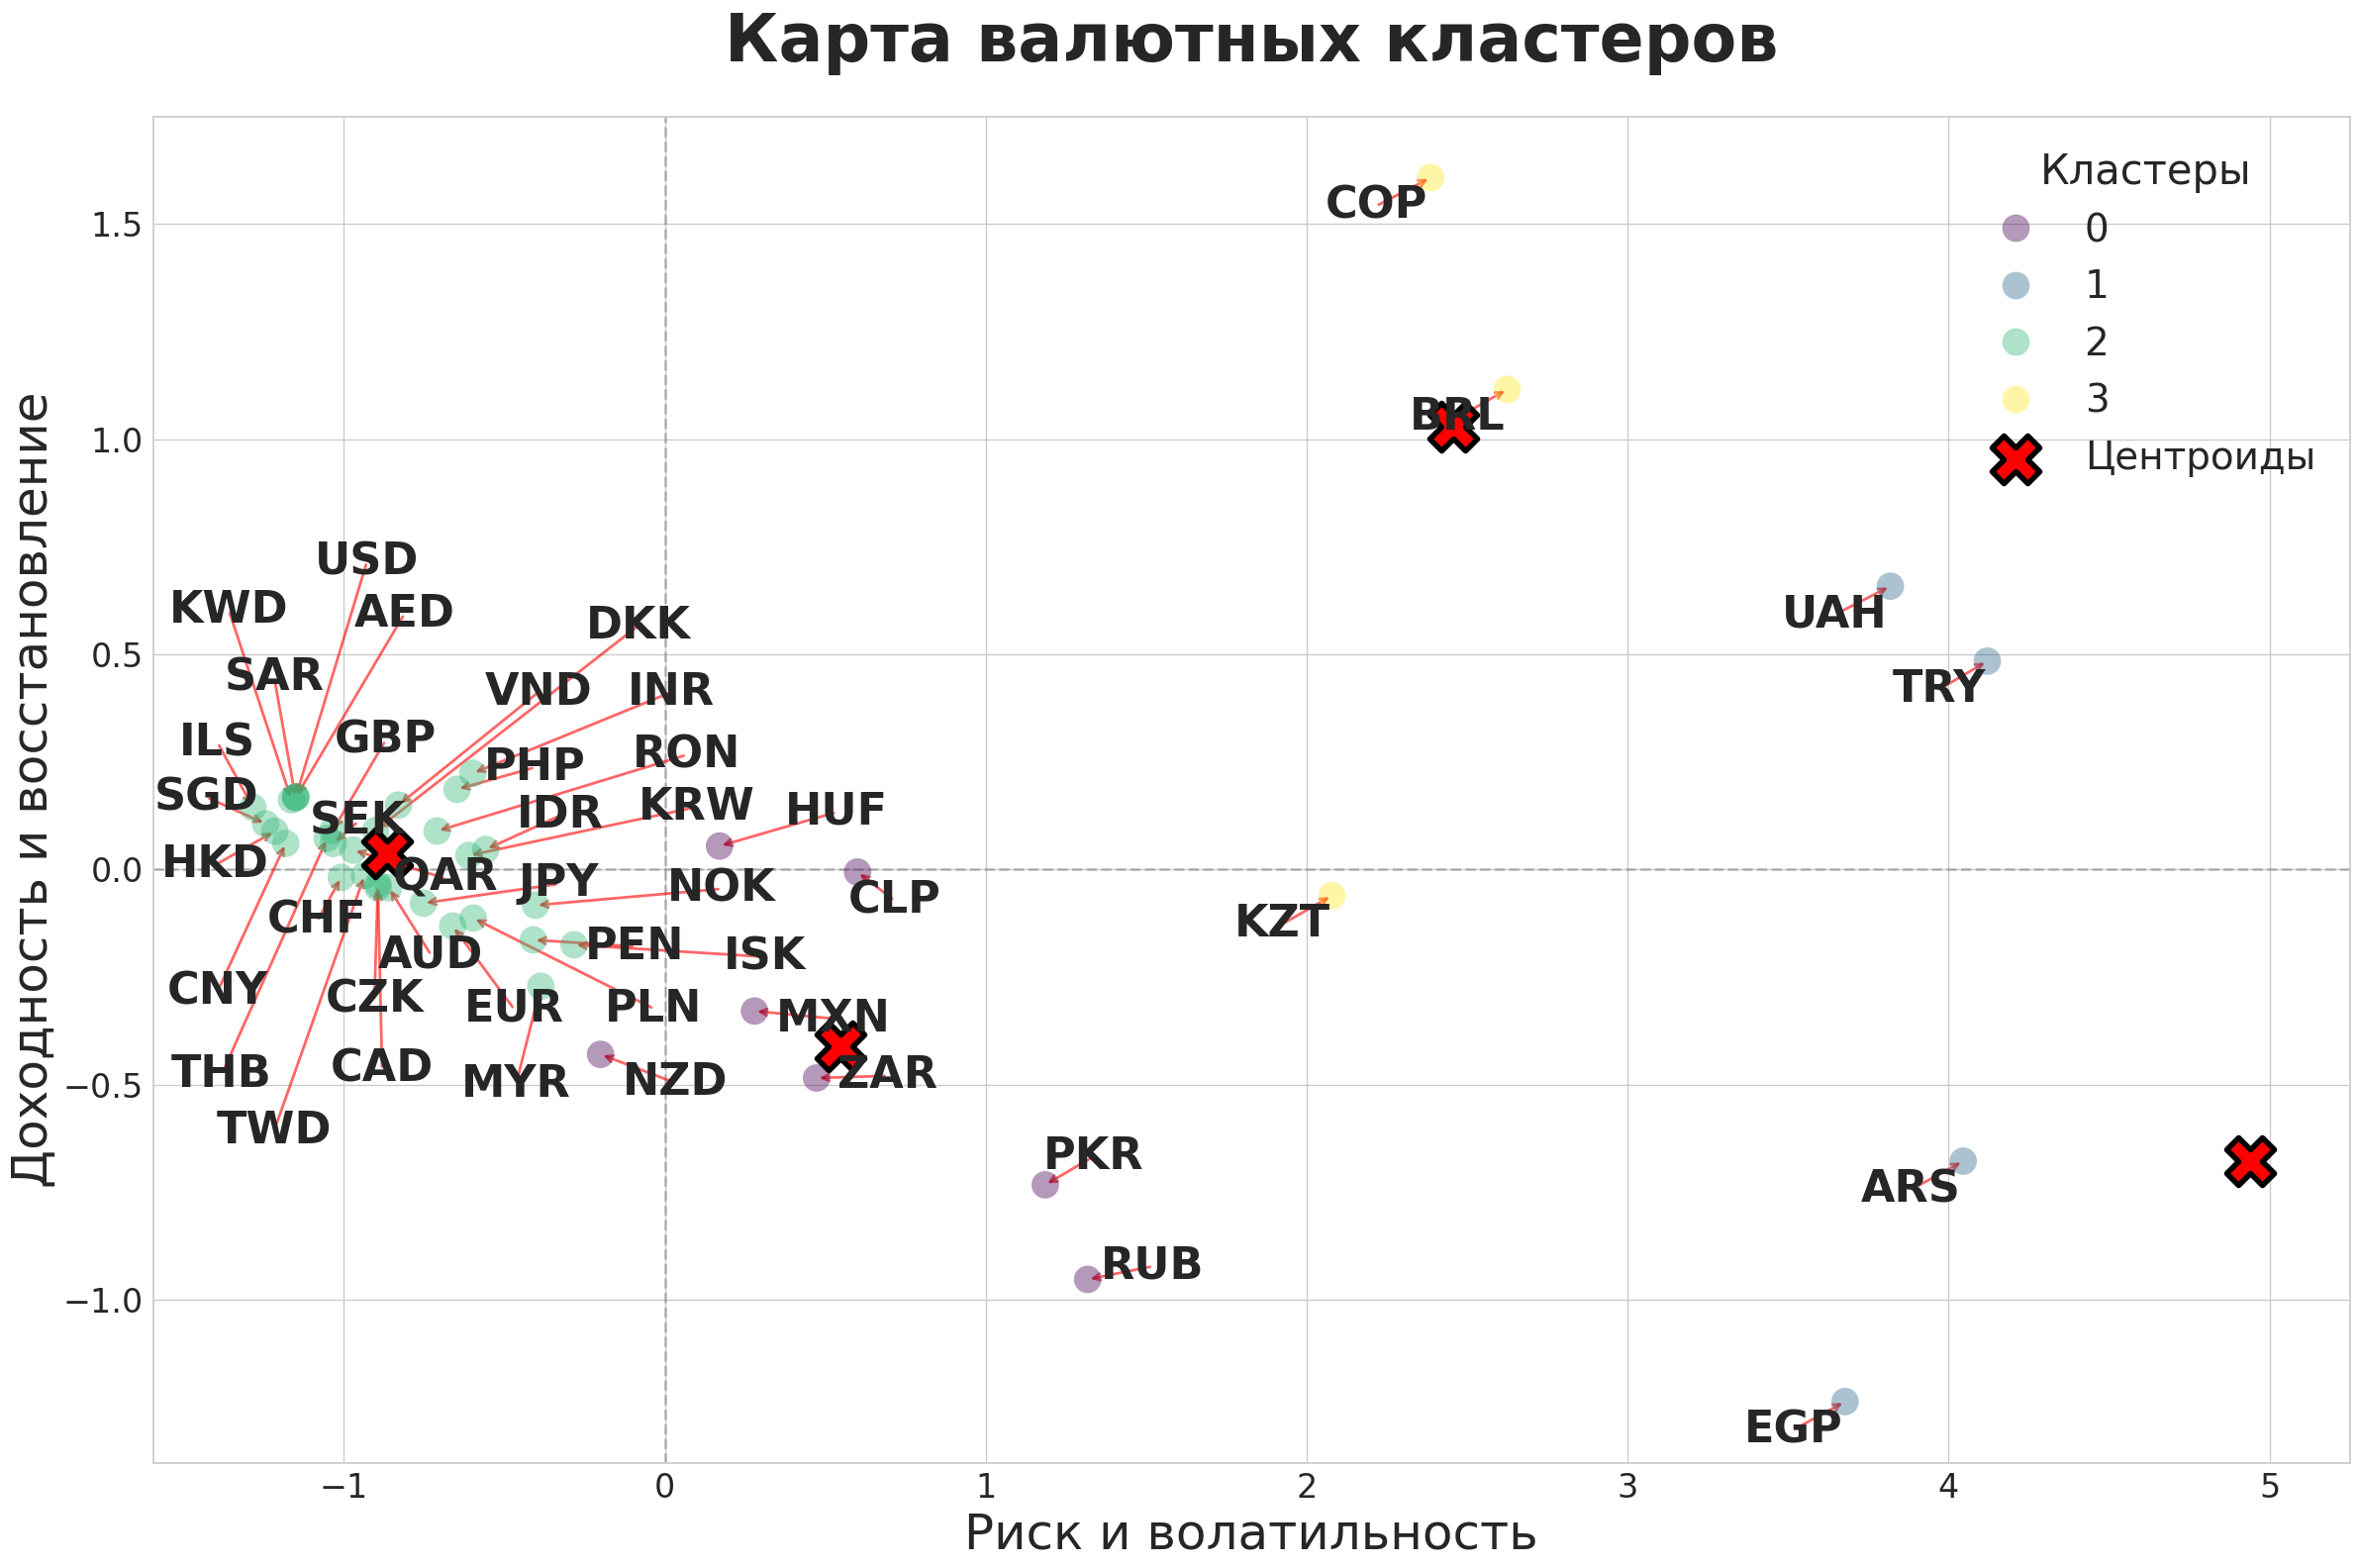

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# 1. Подготовка данных (используем iloc для безопасности)
centroids_scaled = scaler.transform(centroids.drop(columns=['Count']))
centroids_pca = pca.transform(centroids_scaled)

# 2. Создание фигуры увеличенного размера
plt.figure(figsize=(24, 16)) # Еще больше площадь для маневра текста
sns.set_style("whitegrid")

# 3. Отрисовка точек валют
scatter = sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Cluster', 
    palette='viridis', s=400, alpha=0.4, edgecolor='none', zorder=5
)

# 4. Отрисовка центроидов (очень крупные символы)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], 
    marker='X', s=1200, c='red', label='Центроиды',
    edgecolor='black', linewidth=4, zorder=15
)

# 5. Добавление ГИГАНТСКИХ подписей
texts = []
for i in range(pca_df.shape[0]):
    texts.append(plt.text(
        pca_df['PC1'].iloc[i], 
        pca_df['PC2'].iloc[i], 
        pca_df.index[i], 
        fontsize=32,          # Увеличили в два раза относительно предыдущего
        fontweight='bold', 
        ha='center', va='center',
        zorder=20
    ))

# 6. Оптимизация расположения (интенсивное раздвигание)
# arrowprops рисует четкие указатели от текста к точке
adjust_text(texts, 
            expand_points=(2, 2), 
            expand_text=(2, 2),
            force_text=0.8,
            arrowprops=dict(arrowstyle='->', color='red', lw=2, alpha=0.6),
            zorder=25)

# 7. Финальное оформление
plt.title('Карта валютных кластеров', fontsize=48, pad=40, fontweight='bold')
plt.xlabel('Риск и волатильность', fontsize=36)
plt.ylabel('Доходность и восстановление', fontsize=36)

# Укрупнение легенды и меток осей
plt.legend(title='Кластеры', loc='upper right', fontsize=28, title_fontsize=30)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.2)
plt.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.2)

plt.tight_layout()
plt.show()

## 5.3. Финальные «личности» кластеров

На основе анализа средних характеристик (центроидов) и расположения активов на карте, мы присваиваем каждой группе «личность», отражающую её рыночную суть:

### 🟢 Кластер 2: «Тихие гавани» (Global Standards)
* **Профиль**: CAGR 1.72%, Volatility 4.05%, MDD -12.3%.
* **Характер**: Стабильный рост при минимальном риске. Это "ядро" мирового валютного рынка.
* **Состав**: USD, EUR, CHF, GBP, JPY, CNY и еще 25 валют развитых стран.

### 🟣 Кластер 0: «Турбулентные развивающиеся» (Emerging Volatility)
* **Профиль**: CAGR 0.01%, Volatility 7.95%, MDD -32.8%.
* **Характер**: Группа с нулевой доходностью и повышенной волатильностью. Активы, которые постоянно штормит, но они удерживаются от свободного падения.
* **Состав**: RUB, ZAR, MXN, HUF, CLP, PKR, NZD.

### 🟡 Кластер 3: «Зоны долгого восстановления» (Stagnant Risk)
* **Профиль**: CAGR -1.61%, Volatility 9.28%, MDD -47.2%, Recovery ~556 дней.
* **Характер**: Валюты с отрицательной доходностью и крайне тяжелым выходом из просадок. Инвестиция в них может "заморозить" капитал на годы.
* **Состав**: BRL, COP, KZT.

### 🔵 Кластер 1: «Эпицентры девальвации» (Crisis Zone)
* **Профиль**: CAGR -11.07%, Volatility 15.72%, MDD -81.8%.
* **Характер**: Зона финансового бедствия. Глубочайшие обвалы и систематическое обесценивание. Группа практически изолирована от остального мира на карте PCA.
* **Состав**: ARS, TRY, EGP, UAH.

# Этап 6. Итоговый рейтинг и выводы

На заключительном этапе мы трансформируем результаты математического моделирования в прикладной аналитический реестр. Это финальная точка исследования, где «сухие» цифры превращаются в навигатор по мировому валютному рынку с прямым доступом к графической аналитике.

### Что включает в себя этот этап:

1. **Синтез данных и навигация**: Мы объединили рассчитанные риск-метрики (CAGR, Volatility, MDD, Recovery) с результатами кластеризации. Главная особенность — интеграция гиперссылок: каждый тикер в таблице ведет на персональную страницу с графиком абсолютного курса на сайте **abscur.ru**.
2. **Верификация через «личности»**: Вместо технических номеров кластеров мы используем качественные категории: «Тихие гавани», «Зоны девальвации» и другие. Это позволяет мгновенно оценить инвестиционный профиль актива, просто взглянув на его название в списке.
3. **Поиск рыночных аномалий**: Анализ состава групп позволяет выявить «скрытых аутсайдеров» среди развитых экономик и оценить реальную устойчивость валют развивающихся стран. Мы исследуем случаи, когда валюты формально считаются стабильными, но по метрикам попадают в турбулентные зоны.
4. **Прикладной аудит**: Итоговая HTML-таблица служит фундаментом для принятия решений. Вы можете сопоставить математическую просадку (MDD) и скорость восстановления (Recovery) с визуальной картиной на графике, переходя по ссылкам прямо из отчета.

**Результат**: Интерактивная база знаний, структурирующая 45 мировых валют и связывающая результаты машинного обучения с живыми рыночными данными.

In [18]:
from IPython.display import HTML, display

# 1. Словарь имен кластеров
cluster_names = {
    2: "🟢 Тихие гавани",
    0: "🟣 Турбулентные развивающиеся",
    3: "🟡 Зоны долгого восстановления",
    1: "🔴 Эпицентры девальвации"
}

# 2. Подготовка данных
final_report = features_df.copy()
final_report['Cluster_Name'] = final_report['Cluster'].map(cluster_names)

# Формируем HTML-ссылки для тикеров
base_url = "https://www.abscur.ru/p/2.html?abs="
final_report['Asset'] = [
    f'<a href="{base_url}{t}" target="_blank" rel="nofollow" style="color: #1a73e8; font-weight: bold; text-decoration: none;">{t}</a>' 
    for t in final_report.index
]

# Форматируем числовые показатели
final_report['CAGR'] = (final_report['CAGR'] * 100).round(2).astype(str) + '%'
final_report['Volatility'] = (final_report['Volatility'] * 100).round(2).astype(str) + '%'
final_report['Max_Drawdown'] = (final_report['Max_Drawdown'] * 100).round(2).astype(str) + '%'
final_report['Recovery_Days'] = final_report['Recovery_Days'].round(0).astype(int)

# Выбираем колонки и сортируем
cols = ['Asset', 'Cluster_Name', 'CAGR', 'Volatility', 'Max_Drawdown', 'Recovery_Days']
final_display = final_report[cols].sort_values(by='Cluster_Name')

# 3. Генерация и вывод HTML таблицы
# escape=False критически важен, чтобы ссылки не превратились в текст
html_table = final_display.to_html(escape=False, index=False, classes='table table-striped')

print("Итоговый рейтинг валют (кликая по тикеру, вы перейдете к графику):")
display(HTML(html_table))

Итоговый рейтинг валют (кликая по тикеру, вы перейдете к графику):


Asset,Cluster_Name,CAGR,Volatility,Max_Drawdown,Recovery_Days
ARS,🔴 Эпицентры девальвации,-21.16%,19.95%,-99.15%,452
UAH,🔴 Эпицентры девальвации,-3.39%,16.08%,-55.35%,735
TRY,🔴 Эпицентры девальвации,-12.12%,11.38%,-92.31%,653
EGP,🔴 Эпицентры девальвации,-7.62%,15.45%,-80.59%,326
BRL,🟡 Зоны долгого восстановления,-1.42%,10.13%,-46.09%,588
COP,🟡 Зоны долгого восстановления,-0.66%,8.82%,-40.16%,735
KZT,🟡 Зоны долгого восстановления,-2.75%,8.89%,-55.47%,345
AED,🟢 Тихие гавани,2.24%,3.17%,-8.49%,47
MYR,🟢 Тихие гавани,1.86%,5.66%,-22.94%,58
NOK,🟢 Тихие гавани,0.7%,5.26%,-17.42%,85


## 6.1. Визуализация «Риск vs Доходность» (Scatter Plot)

Для финальной проверки качества кластеризации мы построим диаграмму рассеяния, сопоставив две ключевые метрики: **Волатильность** (риск) и **CAGR** (доходность). 

Этот график позволяет наглядно увидеть:
* **Кучность кластеров**: Насколько компактно сгруппированы «Тихие гавани» и как далеко от них находятся «Эпицентры девальвации».
* **Математическую границу**: Где проходит черта между прибыльными активами и теми, чей риск не оправдан доходностью.
* **Положение конкретных валют**: Мы отметили ключевые тикеры (CHF, RUB, TRY и др.), чтобы вы могли соотнести сухие цифры таблицы с их реальным местом в «пищевой цепочке» мирового валютного рынка.


/usr/local/lib/python3.12/dist-packages/adjustText/__init__.py:419: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
/usr/local/lib/python3.12/dist-packages/adjustText/__init__.py:419: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
/usr/local/lib/python3.12/dist-packages/adjustText/__init__.py:419: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
/usr/local/lib/python3.12/dist-packages/adjustText/__init__.py:419: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
/tmp/ipykernel_17/504663232.py:72: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/504663232.py:72: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from fo

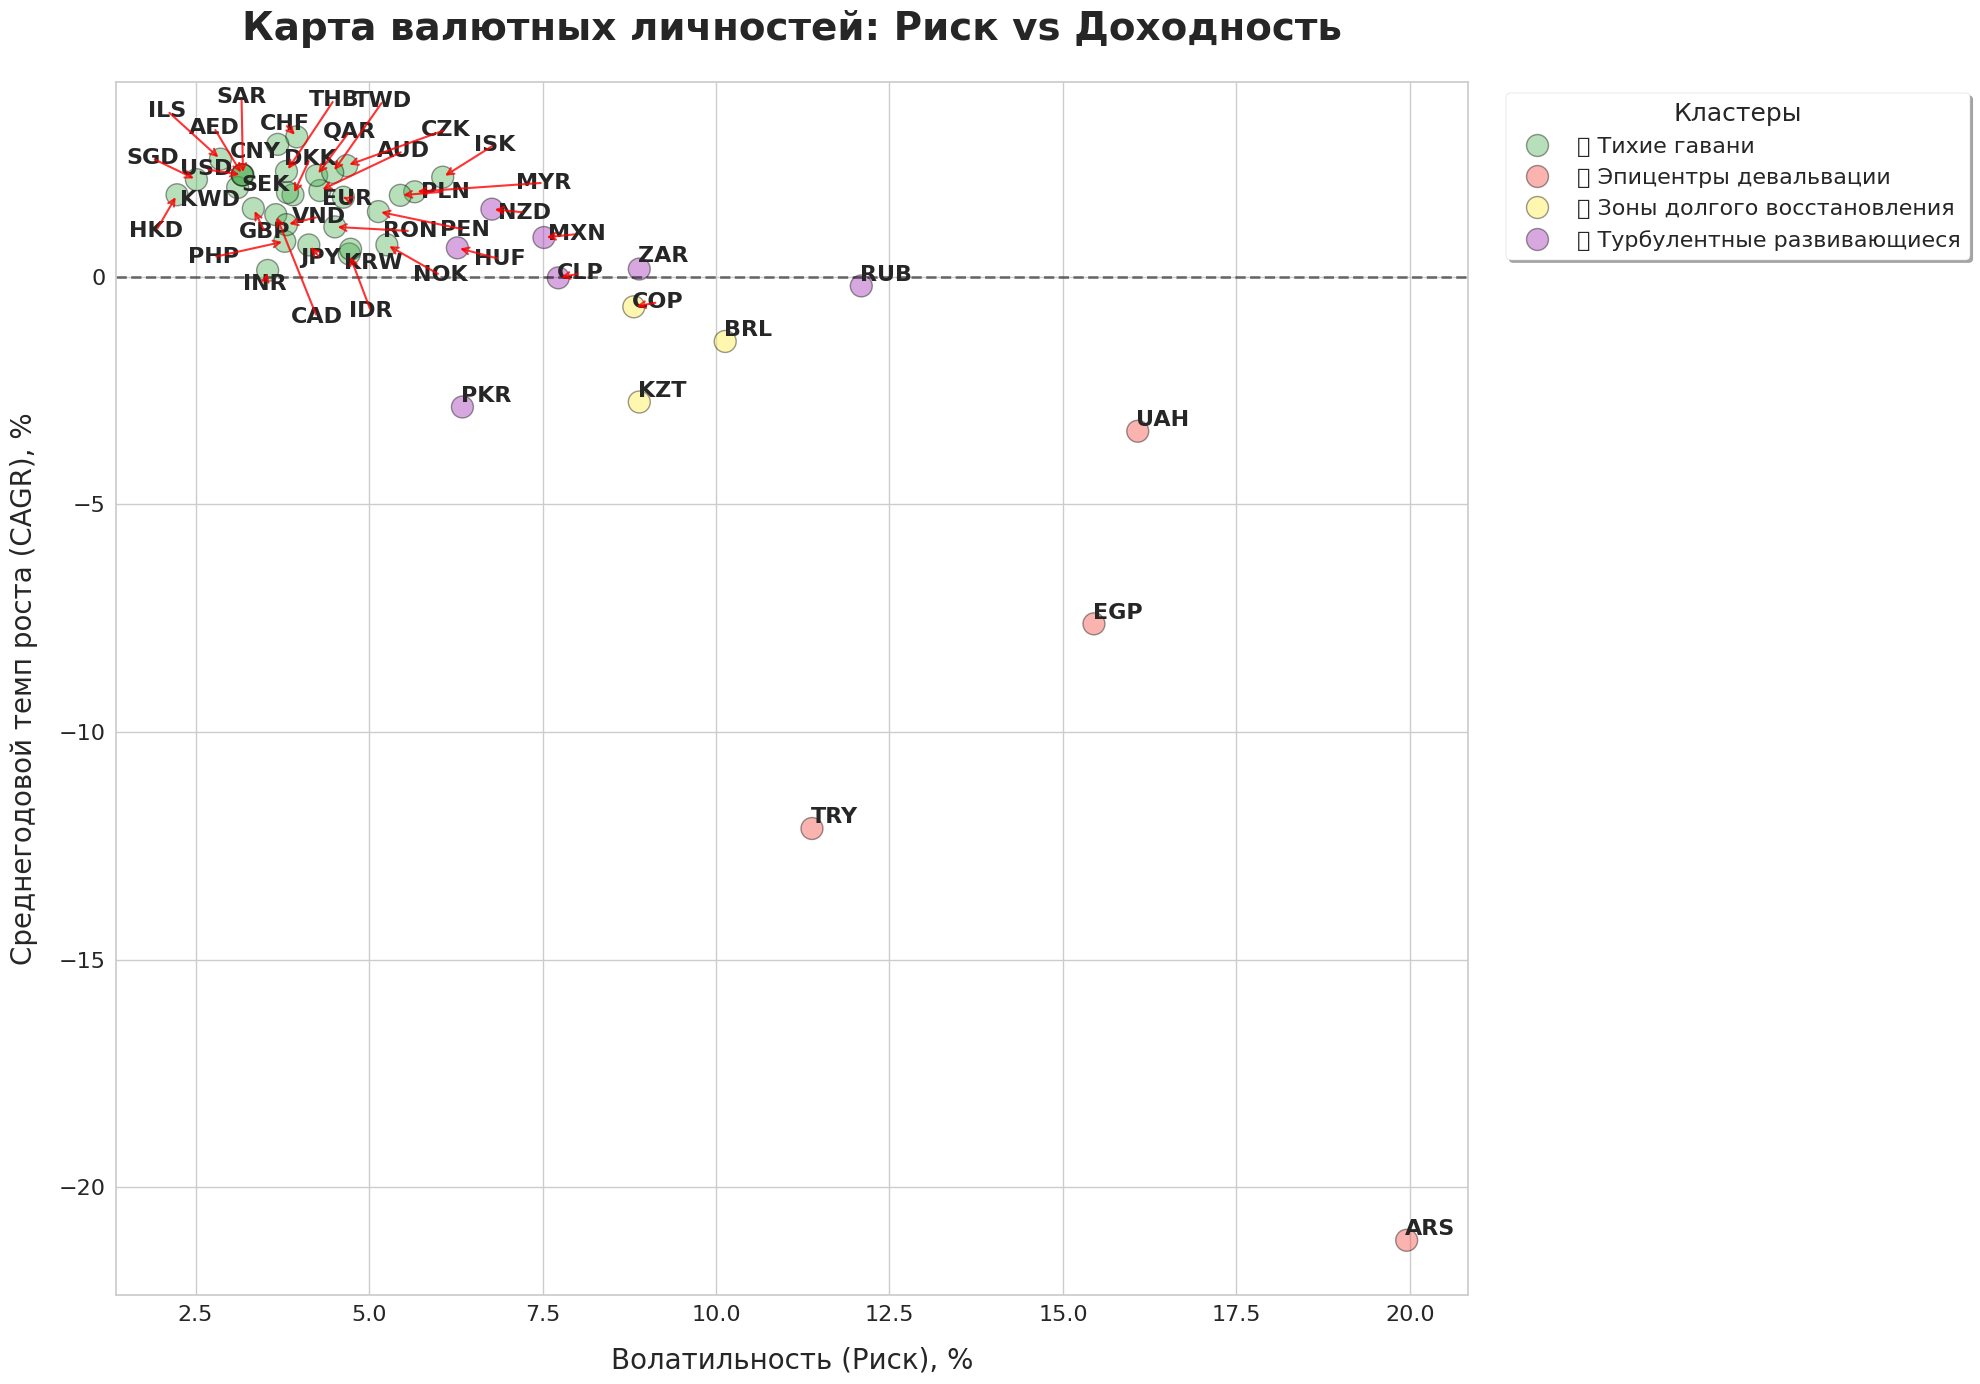

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# 1. Подготовка данных (проценты для осей)
plot_df = features_df.copy()
plot_df['Cluster_Name'] = plot_df['Cluster'].map(cluster_names)
plot_df['CAGR_pct'] = plot_df['CAGR'] * 100
plot_df['Volatility_pct'] = plot_df['Volatility'] * 100

# 2. Настройка стиля и ОГРОМНОГО полотна
# Увеличиваем разрешение (dpi) для четкости текста
plt.figure(figsize=(20, 14), dpi=100) 
sns.set_style("whitegrid")

palette = {
    "🟢 Тихие гавани": "#4caf50",
    "🟣 Турбулентные развивающиеся": "#9c27b0",
    "🟡 Зоны долгого восстановления": "#ffeb3b",
    "🔴 Эпицентры девальвации": "#f44336"
}

# 3. Построение точек (делаем их крупнее)
scatter = sns.scatterplot(
    data=plot_df, 
    x='Volatility_pct', 
    y='CAGR_pct', 
    hue='Cluster_Name', 
    palette=palette,
    s=250, 
    alpha=0.4, 
    edgecolor='black',
    linewidth=1
)

# 4. Создание списка подписей (Шрифт 16 - это очень крупно для графиков)
texts = []
for ticker in plot_df.index:
    texts.append(plt.text(
        plot_df.loc[ticker, 'Volatility_pct'], 
        plot_df.loc[ticker, 'CAGR_pct'], 
        ticker, 
        fontsize=16, # Огромный шрифт
        fontweight='black' # Максимальная жирность
    ))

# 5. Умное выравнивание с акцентом на выноски
# expand_text=(2.5, 2.5) — заставляем текст разлетаться очень далеко
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.8), # Красные стрелки для видимости
    expand_text=(2.5, 2.5), 
    expand_points=(2, 2),
    force_text=(0.5, 0.5),
    ensure_inside_axes=True
)

# 6. Оформление (крупные заголовки)
plt.title('Карта валютных личностей: Риск vs Доходность', fontsize=28, pad=30, fontweight='bold')
plt.xlabel('Волатильность (Риск), %', fontsize=20, labelpad=15)
plt.ylabel('Среднегодовой темп роста (CAGR), %', fontsize=20, labelpad=15)

# Настройка легенды (тоже крупно)
plt.legend(title='Кластеры', bbox_to_anchor=(1.02, 1), loc='upper left', 
           fontsize=16, title_fontsize=18, frameon=True, shadow=True)

# Сетки и линии
plt.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()

# Сохраняем в высоком качестве для блога
plt.savefig('currency_personalities_high_res.png', dpi=300, bbox_inches='tight')
plt.show()